# 09 — Combined Public Augmentation Expansion

This notebook tests whether stronger combined public-data augmentation recipes improve the public-data segmentation recipe selected in Notebook 07.

This is the first notebook in a three-notebook generalization-optimization workflow:

1. **Notebook 09** screens combined public-data augmentation recipes using public validation performance.
2. **Notebook 10** retrains the best Notebook 09 recipe longer on public data only.
3. **Notebook 11** evaluates the Notebook 10 model on the clinical PSD-derived dataset and compares it to Notebook 08.

Clinical data are not used in this notebook. The purpose here is to choose a stronger public-data recipe without using the clinical set as a tuning target.

In [1]:
# 09.01 — Imports

from __future__ import annotations

import copy
import json
import math
import os
import platform
import sys
import time
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display


In [2]:
# 09.02 — Project root and source path setup

def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root by walking upward to the .git directory."""
    current = Path.cwd() if start is None else Path(start).resolve()

    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists():
            return candidate

    raise FileNotFoundError("Could not find project root containing .git.")


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

os.chdir(PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT.name}")
print(f"Source directory available: {SRC_DIR.exists()}")
print(f"Python executable: {sys.executable}")
print(f"Python version: {platform.python_version()}")


Project root: Automated-Glaucoma-Screening-Using-AI-Enhanced-Ophthalmoscopy
Source directory available: True
Python executable: /home/gsr3qz/.conda/envs/glaucoma-capstone/bin/python
Python version: 3.11.15


In [3]:
# 09.03 — Paths and output directories

MANIFEST_PATH = PROJECT_ROOT / "data/processed/manifests/combined_segmentation_manifest_with_splits.csv"

REPORTS_DIR = PROJECT_ROOT / "reports"
TRAINING_REPORT_DIR = REPORTS_DIR / "training"
DATA_AUDIT_REPORT_DIR = REPORTS_DIR / "data_audit"

TRAINING_REPORT_DIR.mkdir(parents=True, exist_ok=True)
DATA_AUDIT_REPORT_DIR.mkdir(parents=True, exist_ok=True)

NOTEBOOK_07_SUMMARY_PATH = TRAINING_REPORT_DIR / "final_model_selection_summary.csv"
NOTEBOOK_08_IMAGE_WEIGHTED_PATH = TRAINING_REPORT_DIR / "clinical_generalization_evaluation_summary.csv"
NOTEBOOK_08_PATIENT_WEIGHTED_PATH = TRAINING_REPORT_DIR / "clinical_generalization_patient_weighted_summary.csv"

PLAN_PATH = TRAINING_REPORT_DIR / "combined_public_augmentation_plan.csv"
HISTORY_PATH = TRAINING_REPORT_DIR / "combined_public_augmentation_training_history.csv"
METADATA_PATH = TRAINING_REPORT_DIR / "combined_public_augmentation_run_metadata.csv"
VALIDATION_SUMMARY_PATH = TRAINING_REPORT_DIR / "combined_public_augmentation_validation_summary.csv"
SUMMARY_PATH = TRAINING_REPORT_DIR / "combined_public_augmentation_summary.csv"
DATASET_SUMMARY_PATH = DATA_AUDIT_REPORT_DIR / "combined_public_augmentation_dataset_summary.csv"

paths = pd.DataFrame(
    [
        {"artifact": "combined public manifest", "path": MANIFEST_PATH, "exists": MANIFEST_PATH.exists()},
        {"artifact": "Notebook 07 final summary", "path": NOTEBOOK_07_SUMMARY_PATH, "exists": NOTEBOOK_07_SUMMARY_PATH.exists()},
        {"artifact": "Notebook 08 image-weighted clinical summary", "path": NOTEBOOK_08_IMAGE_WEIGHTED_PATH, "exists": NOTEBOOK_08_IMAGE_WEIGHTED_PATH.exists()},
        {"artifact": "Notebook 08 patient-weighted clinical summary", "path": NOTEBOOK_08_PATIENT_WEIGHTED_PATH, "exists": NOTEBOOK_08_PATIENT_WEIGHTED_PATH.exists()},
        {"artifact": "Notebook 09 plan output", "path": PLAN_PATH, "exists": PLAN_PATH.exists()},
        {"artifact": "Notebook 09 history output", "path": HISTORY_PATH, "exists": HISTORY_PATH.exists()},
        {"artifact": "Notebook 09 validation summary output", "path": VALIDATION_SUMMARY_PATH, "exists": VALIDATION_SUMMARY_PATH.exists()},
    ]
)

display(paths.assign(path=paths["path"].map(lambda path: str(Path(path).relative_to(PROJECT_ROOT)))))

missing_required = paths.loc[
    paths["artifact"].isin(["combined public manifest", "Notebook 07 final summary"])
    & ~paths["exists"],
    "artifact",
].tolist()

if missing_required:
    raise FileNotFoundError(f"Missing required Notebook 09 inputs: {missing_required}")


,artifact,path,exists
0,combined public manifest,data/processed/manifests/combined_segmentation...,True
1,Notebook 07 final summary,reports/training/final_model_selection_summary...,True
2,Notebook 08 image-weighted clinical summary,reports/training/clinical_generalization_evalu...,True
3,Notebook 08 patient-weighted clinical summary,reports/training/clinical_generalization_patie...,True
4,Notebook 09 plan output,reports/training/combined_public_augmentation_...,True
5,Notebook 09 history output,reports/training/combined_public_augmentation_...,True
6,Notebook 09 validation summary output,reports/training/combined_public_augmentation_...,True


In [4]:
# 09.04 — Core project module import check

from glaucoma_segmentation.augmentation import (
    build_online_augmentation_preset,
    build_virtual_synthetic_expansion_dataset,
    combined_online_augmentation_components,
    describe_combined_online_augmentation_presets,
    describe_online_augmentation_presets,
    summarize_virtual_synthetic_expansion,
    supported_combined_online_augmentation_presets,
    supported_online_augmentation_presets,
)
from glaucoma_segmentation.data.dataloaders import (
    make_segmentation_dataloader,
    make_segmentation_datasets,
)
from glaucoma_segmentation.nets.losses import DiceCELoss
from glaucoma_segmentation.nets.model_factory import build_model
from glaucoma_segmentation.training.train_loop import (
    extract_images_and_masks,
    history_to_dicts,
    model_forward,
    run_one_epoch_with_progress,
)
from glaucoma_segmentation.utils.device import describe_device, device_summary_dict, get_device
from glaucoma_segmentation.utils.seed import seed_everything

default_presets = supported_online_augmentation_presets()
combined_presets = supported_combined_online_augmentation_presets()

print("Default presets:", default_presets)
print("Combined presets:", combined_presets)

expected_default_presets = (
    "none",
    "horizontal_flip",
    "small_affine",
    "global_photometric",
    "defocus_blur",
    "low_resolution",
    "jpeg_compression",
    "vignette_illumination",
)

if default_presets != expected_default_presets:
    raise RuntimeError(
        "Default online preset list changed unexpectedly. "
        f"Observed={default_presets}, expected={expected_default_presets}."
    )

for preset_name in combined_presets:
    transform = build_online_augmentation_preset(preset_name)
    print(f"{preset_name}: {type(transform).__name__}")

print("Core project imports: OK")


/home/gsr3qz/.conda/envs/glaucoma-capstone/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Default presets: ('none', 'horizontal_flip', 'small_affine', 'global_photometric', 'defocus_blur', 'low_resolution', 'jpeg_compression', 'vignette_illumination')
Combined presets: ('combo_small_affine_photometric', 'combo_small_affine_blur', 'combo_small_affine_vignette', 'combo_affine_photometric_blur', 'combo_affine_vignette_blur', 'combo_full_robustness')
combo_small_affine_photometric: ComposeSampleTransforms
combo_small_affine_blur: ComposeSampleTransforms
combo_small_affine_vignette: ComposeSampleTransforms
combo_affine_photometric_blur: ComposeSampleTransforms
combo_affine_vignette_blur: ComposeSampleTransforms
combo_full_robustness: ComposeSampleTransforms
Core project imports: OK


In [5]:
# 09.05 — Experiment configuration

SEED = 42
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 8
EPOCHS = 5
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
ENCODER_WEIGHTS = None
NUM_CLASSES = 3
PIN_MEMORY = torch.cuda.is_available()

cpu_count = os.cpu_count() or 2
NUM_WORKERS = min(4, max(1, cpu_count - 1))

PRIMARY_METRIC = "val_mean_foreground_dice"
MEANINGFUL_DICE_DELTA = 0.005

# Set True only when intentionally replacing existing Notebook 09 outputs.
FORCE_RERUN = False

seed_config = seed_everything(SEED, deterministic=False)
DEVICE = get_device()
DEVICE_INFO = device_summary_dict(DEVICE)

config = {
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "encoder_weights": ENCODER_WEIGHTS,
    "num_classes": NUM_CLASSES,
    "num_workers": NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
    "primary_metric": PRIMARY_METRIC,
    "meaningful_dice_delta": MEANINGFUL_DICE_DELTA,
    "device": str(DEVICE),
    "seed_config": seed_config,
}

display(pd.DataFrame([config | DEVICE_INFO]))


,seed,image_size,batch_size,epochs,learning_rate,weight_decay,encoder_weights,num_classes,num_workers,pin_memory,primary_metric,meaningful_dice_delta,device,seed_config,device_type,name,cuda_available,cuda_device_count,mps_available
0,42,"(256, 256)",8,5,0.0001,0.0001,None,3,4,True,val_mean_foreground_dice,0.005,cuda,"SeedConfig(seed=42, deterministic=False, cudnn...",cuda,NVIDIA RTX A6000,True,1,False


## Screening rule

Notebook 09 screens combined public-data augmentation recipes using public validation performance only.

The clinical PSD-derived data are not used here. The purpose is to avoid turning the small clinical dataset into a tuning set. Clinical generalization is reserved for Notebook 11 after the best Notebook 09 recipe is retrained longer in Notebook 10.

In [6]:
# 09.06 — Review Notebook 07 and Notebook 08 reference results

notebook_07_summary = pd.read_csv(NOTEBOOK_07_SUMMARY_PATH)

if "test_mean_foreground_dice" in notebook_07_summary.columns:
    notebook_07_reference = (
        notebook_07_summary
        .sort_values("test_mean_foreground_dice", ascending=False)
        .iloc[0]
        .to_dict()
    )
else:
    notebook_07_reference = notebook_07_summary.iloc[0].to_dict()

notebook_07_reference_frame = pd.DataFrame([notebook_07_reference])
display(notebook_07_reference_frame)

reference_run_name = str(notebook_07_reference.get("run_name", "notebook_07_selected_model"))
reference_val_mean_foreground_dice = float(
    notebook_07_reference.get(
        "val_mean_foreground_dice",
        notebook_07_reference.get("best_val_mean_foreground_dice", np.nan),
    )
)
reference_test_mean_foreground_dice = float(
    notebook_07_reference.get("test_mean_foreground_dice", np.nan)
)

clinical_reference_rows = []

if NOTEBOOK_08_IMAGE_WEIGHTED_PATH.exists():
    image_weighted = pd.read_csv(NOTEBOOK_08_IMAGE_WEIGHTED_PATH).iloc[0].to_dict()
    clinical_reference_rows.append(
        {
            "reference": "Notebook 08 clinical image-weighted",
            "mean_foreground_dice": image_weighted.get("image_weighted_mean_foreground_dice_mean", np.nan),
            "disc_dice": image_weighted.get("image_weighted_disc_dice_mean", np.nan),
            "cup_dice": image_weighted.get("image_weighted_cup_dice_mean", np.nan),
            "cdr_abs_error": image_weighted.get("image_weighted_cdr_abs_error_mean", np.nan),
        }
    )

if NOTEBOOK_08_PATIENT_WEIGHTED_PATH.exists():
    patient_weighted = pd.read_csv(NOTEBOOK_08_PATIENT_WEIGHTED_PATH).iloc[0].to_dict()
    clinical_reference_rows.append(
        {
            "reference": "Notebook 08 clinical patient-weighted",
            "mean_foreground_dice": patient_weighted.get("patient_weighted_mean_foreground_dice_mean", np.nan),
            "disc_dice": patient_weighted.get("patient_weighted_disc_dice_mean", np.nan),
            "cup_dice": patient_weighted.get("patient_weighted_cup_dice_mean", np.nan),
            "cdr_abs_error": patient_weighted.get("patient_weighted_cdr_abs_error_mean", np.nan),
        }
    )

if clinical_reference_rows:
    display(pd.DataFrame(clinical_reference_rows))

print(f"Notebook 07 reference run: {reference_run_name}")
print(f"Notebook 07 reference validation mean foreground Dice: {reference_val_mean_foreground_dice:.6f}")
print(f"Notebook 07 reference public test mean foreground Dice: {reference_test_mean_foreground_dice:.6f}")


,run_name,model_name,encoder_name,strategy_name,augmentation_mode,candidate_role,best_epoch_by_val_mean_foreground_dice,best_val_loss,best_val_disc_dice,best_val_cup_dice,...,total_fit_and_test_minutes,candidate_priority,selection_rationale,validation_mean_foreground_dice,online_reference_mean_foreground_dice,delta_vs_online_reference,public_test_rank,selected_for_notebook_08_clinical_generalization,test_margin_over_next_best,meaningful_test_margin_over_next
0,final_unetplusplus_resnet18_small_affine_virtu...,unetplusplus,resnet18,small_affine,virtual_synthetic_add_back,primary_public_test_finalist,4,0.135512,0.847783,0.798071,...,18.088981,1,Best validation mean foreground Dice from the ...,0.819174,0.811561,0.007612,1,True,0.003962,False


,reference,mean_foreground_dice,disc_dice,cup_dice,cdr_abs_error
0,Notebook 08 clinical image-weighted,0.317713,0.377686,0.257740,0.290072
1,Notebook 08 clinical patient-weighted,0.242017,0.267402,0.216632,0.283353


Notebook 07 reference run: final_unetplusplus_resnet18_small_affine_virtual_synthetic_256px_5epoch
Notebook 07 reference validation mean foreground Dice: 0.822927
Notebook 07 reference public test mean foreground Dice: 0.817976


In [7]:
# 09.07 — Define combined augmentation candidate plan

candidate_strategy_names = [
    "combo_small_affine_photometric",
    "combo_small_affine_blur",
    "combo_small_affine_vignette",
    "combo_affine_photometric_blur",
    "combo_affine_vignette_blur",
    "combo_full_robustness",
]

candidate_records: list[dict[str, object]] = []

for strategy_name in candidate_strategy_names:
    components = combined_online_augmentation_components(strategy_name)
    run_name = f"combined_unetplusplus_resnet18_{strategy_name}_virtual_synthetic_256px_5epoch"

    candidate_records.append(
        {
            "run_name": run_name,
            "model_name": "unetplusplus",
            "encoder_name": "resnet18",
            "encoder_weights": ENCODER_WEIGHTS,
            "strategy_name": strategy_name,
            "component_strategies": ";".join(components),
            "augmentation_mode": "virtual_synthetic_add_back",
            "synthetic_copy_count": 1,
            "include_original_train_rows": True,
            "materializes_synthetic_files": False,
            "image_size": str(IMAGE_SIZE),
            "batch_size": BATCH_SIZE,
            "epochs": EPOCHS,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "selection_metric": PRIMARY_METRIC,
            "candidate_rationale": (
                "Screen a composed public-data robustness recipe while keeping the "
                "Notebook 07 selected architecture fixed."
            ),
        }
    )

candidate_plan = pd.DataFrame(candidate_records)
candidate_plan.to_csv(PLAN_PATH, index=False)

display(candidate_plan)
print(f"Saved candidate plan: {PLAN_PATH.relative_to(PROJECT_ROOT)}")


,run_name,model_name,encoder_name,encoder_weights,strategy_name,component_strategies,augmentation_mode,synthetic_copy_count,include_original_train_rows,materializes_synthetic_files,image_size,batch_size,epochs,learning_rate,weight_decay,selection_metric,candidate_rationale
0,combined_unetplusplus_resnet18_combo_small_aff...,unetplusplus,resnet18,None,combo_small_affine_photometric,small_affine;global_photometric,virtual_synthetic_add_back,1,True,False,"(256, 256)",8,5,0.0001,0.0001,val_mean_foreground_dice,Screen a composed public-data robustness recip...
1,combined_unetplusplus_resnet18_combo_small_aff...,unetplusplus,resnet18,None,combo_small_affine_blur,small_affine;defocus_blur,virtual_synthetic_add_back,1,True,False,"(256, 256)",8,5,0.0001,0.0001,val_mean_foreground_dice,Screen a composed public-data robustness recip...
2,combined_unetplusplus_resnet18_combo_small_aff...,unetplusplus,resnet18,None,combo_small_affine_vignette,small_affine;vignette_illumination,virtual_synthetic_add_back,1,True,False,"(256, 256)",8,5,0.0001,0.0001,val_mean_foreground_dice,Screen a composed public-data robustness recip...
3,combined_unetplusplus_resnet18_combo_affine_ph...,unetplusplus,resnet18,None,combo_affine_photometric_blur,small_affine;global_photometric;defocus_blur,virtual_synthetic_add_back,1,True,False,"(256, 256)",8,5,0.0001,0.0001,val_mean_foreground_dice,Screen a composed public-data robustness recip...
4,combined_unetplusplus_resnet18_combo_affine_vi...,unetplusplus,resnet18,None,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,virtual_synthetic_add_back,1,True,False,"(256, 256)",8,5,0.0001,0.0001,val_mean_foreground_dice,Screen a composed public-data robustness recip...
5,combined_unetplusplus_resnet18_combo_full_robu...,unetplusplus,resnet18,None,combo_full_robustness,small_affine;global_photometric;defocus_blur;l...,virtual_synthetic_add_back,1,True,False,"(256, 256)",8,5,0.0001,0.0001,val_mean_foreground_dice,Screen a composed public-data robustness recip...


Saved candidate plan: reports/training/combined_public_augmentation_plan.csv


In [8]:
# 09.08 — Build original public split datasets

datasets = make_segmentation_datasets(
    manifest_path=MANIFEST_PATH,
    splits=("train", "val", "test"),
    image_size=IMAGE_SIZE,
    validate_paths=True,
    validate_masks=True,
)

if datasets.train is None or datasets.val is None or datasets.test is None:
    raise RuntimeError("Expected train, validation, and test datasets to be available.")

split_counts = {
    "train_rows": len(datasets.train),
    "val_rows": len(datasets.val),
    "test_rows": len(datasets.test),
}

expected_counts = {
    "train_rows": 1911,
    "val_rows": 725,
    "test_rows": 722,
}

print(split_counts)

for key, expected_value in expected_counts.items():
    observed_value = split_counts[key]
    if observed_value != expected_value:
        raise RuntimeError(f"Unexpected {key}: observed={observed_value}, expected={expected_value}")

dataset_reference_summary = pd.DataFrame(
    [
        {
            "dataset_role": "original_public_train",
            "rows": len(datasets.train),
            "wrapped_for_virtual_synthetic": False,
            "used_for_training": True,
            "used_for_validation": False,
            "used_for_test": False,
        },
        {
            "dataset_role": "original_public_val",
            "rows": len(datasets.val),
            "wrapped_for_virtual_synthetic": False,
            "used_for_training": False,
            "used_for_validation": True,
            "used_for_test": False,
        },
        {
            "dataset_role": "original_public_test",
            "rows": len(datasets.test),
            "wrapped_for_virtual_synthetic": False,
            "used_for_training": False,
            "used_for_validation": False,
            "used_for_test": False,
        },
    ]
)

display(dataset_reference_summary)


{'train_rows': 1911, 'val_rows': 725, 'test_rows': 722}


,dataset_role,rows,wrapped_for_virtual_synthetic,used_for_training,used_for_validation,used_for_test
0,original_public_train,1911,False,True,False,False
1,original_public_val,725,False,False,True,False
2,original_public_test,722,False,False,False,False


In [9]:
# 09.09 — Build virtual synthetic datasets for combined recipes

virtual_train_datasets = {}
dataset_summary_records: list[dict[str, object]] = []

for row in candidate_plan.to_dict("records"):
    run_name = str(row["run_name"])
    strategy_name = str(row["strategy_name"])
    copy_count = int(row["synthetic_copy_count"])

    virtual_dataset = build_virtual_synthetic_expansion_dataset(
        base_dataset=datasets.train,
        strategy_names=strategy_name,
        copy_count=copy_count,
        base_seed=SEED,
        include_original=True,
        add_metadata=True,
    )
    virtual_train_datasets[run_name] = virtual_dataset

    summary = summarize_virtual_synthetic_expansion(virtual_dataset)
    dataset_summary_records.append(
        {
            "run_name": run_name,
            "model_name": row["model_name"],
            "encoder_name": row["encoder_name"],
            "strategy_name": strategy_name,
            "component_strategies": row["component_strategies"],
            **summary,
            "validation_rows": len(datasets.val),
            "test_rows_available_but_not_used_for_screening": len(datasets.test),
            "materializes_synthetic_files": False,
        }
    )

dataset_summary = pd.DataFrame(dataset_summary_records)
dataset_summary.to_csv(DATASET_SUMMARY_PATH, index=False)

display(dataset_summary)
print(f"Saved dataset summary: {DATASET_SUMMARY_PATH.relative_to(PROJECT_ROOT)}")


,run_name,model_name,encoder_name,strategy_name,component_strategies,base_rows,original_rows_exposed,synthetic_rows_exposed,total_rows_exposed,base_seed,include_original,strategies,copy_counts,validation_rows,test_rows_available_but_not_used_for_screening,materializes_synthetic_files
0,combined_unetplusplus_resnet18_combo_small_aff...,unetplusplus,resnet18,combo_small_affine_photometric,small_affine;global_photometric,1911,1911,1911,3822,42,True,combo_small_affine_photometric,1,725,722,False
1,combined_unetplusplus_resnet18_combo_small_aff...,unetplusplus,resnet18,combo_small_affine_blur,small_affine;defocus_blur,1911,1911,1911,3822,42,True,combo_small_affine_blur,1,725,722,False
2,combined_unetplusplus_resnet18_combo_small_aff...,unetplusplus,resnet18,combo_small_affine_vignette,small_affine;vignette_illumination,1911,1911,1911,3822,42,True,combo_small_affine_vignette,1,725,722,False
3,combined_unetplusplus_resnet18_combo_affine_ph...,unetplusplus,resnet18,combo_affine_photometric_blur,small_affine;global_photometric;defocus_blur,1911,1911,1911,3822,42,True,combo_affine_photometric_blur,1,725,722,False
4,combined_unetplusplus_resnet18_combo_affine_vi...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,1911,1911,1911,3822,42,True,combo_affine_vignette_blur,1,725,722,False
5,combined_unetplusplus_resnet18_combo_full_robu...,unetplusplus,resnet18,combo_full_robustness,small_affine;global_photometric;defocus_blur;l...,1911,1911,1911,3822,42,True,combo_full_robustness,1,725,722,False


Saved dataset summary: reports/data_audit/combined_public_augmentation_dataset_summary.csv


In [10]:
# 09.10 — Dataloader and transform smoke tests

first_candidate = candidate_plan.iloc[0].to_dict()
first_run_name = str(first_candidate["run_name"])

smoke_train_loader = make_segmentation_dataloader(
    virtual_train_datasets[first_run_name],
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)
smoke_val_loader = make_segmentation_dataloader(
    datasets.val,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)

smoke_batch = next(iter(smoke_train_loader))
smoke_images, smoke_masks = extract_images_and_masks(smoke_batch)

smoke_summary = {
    "first_run_name": first_run_name,
    "train_batch_image_shape": tuple(smoke_images.shape),
    "train_batch_mask_shape": tuple(smoke_masks.shape),
    "image_min": float(smoke_images.min()),
    "image_max": float(smoke_images.max()),
    "mask_values": sorted(int(value) for value in torch.unique(smoke_masks).tolist()),
    "is_synthetic_values": sorted(bool(value) for value in smoke_batch.get("is_synthetic", torch.tensor([])).tolist()),
    "synthetic_strategy_preview": list(smoke_batch.get("synthetic_strategy", []))[:8],
    "train_batches_smoke": len(smoke_train_loader),
    "val_batches_smoke": len(smoke_val_loader),
}

display(pd.DataFrame([smoke_summary]))

if not set(smoke_summary["mask_values"]).issubset({0, 1, 2}):
    raise RuntimeError(f"Unexpected mask values: {smoke_summary['mask_values']}")

if smoke_images.ndim != 4 or smoke_masks.ndim != 3:
    raise RuntimeError("Unexpected image/mask batch dimensions.")

print("Dataloader and transform smoke test: OK")


,first_run_name,train_batch_image_shape,train_batch_mask_shape,image_min,image_max,mask_values,is_synthetic_values,synthetic_strategy_preview,train_batches_smoke,val_batches_smoke
0,combined_unetplusplus_resnet18_combo_small_aff...,"(8, 3, 256, 256)","(8, 256, 256)",0.0,1.0,"[0, 1, 2]","[False, False, False, False, True, True, True,...","[combo_small_affine_photometric, none, combo_s...",478,91


Dataloader and transform smoke test: OK


In [11]:
# 09.11 — Model/loss smoke test

seed_everything(SEED, deterministic=False)

smoke_model = build_model(
    model_name="unetplusplus",
    in_channels=3,
    classes=NUM_CLASSES,
    encoder_name="resnet18",
    encoder_weights=ENCODER_WEIGHTS,
).to(DEVICE)

criterion = DiceCELoss()
smoke_images_device = smoke_images.to(DEVICE).float()
smoke_masks_device = smoke_masks.to(DEVICE).long()

smoke_logits = model_forward(smoke_model, smoke_images_device)
smoke_loss = criterion(smoke_logits, smoke_masks_device)

print("logits shape:", tuple(smoke_logits.shape))
print("loss:", float(smoke_loss.detach().cpu()))

if smoke_logits.shape[:2] != (smoke_images.shape[0], NUM_CLASSES):
    raise RuntimeError(f"Unexpected logits shape: {tuple(smoke_logits.shape)}")

del smoke_model, smoke_logits, smoke_loss, smoke_images_device, smoke_masks_device

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Model/loss smoke test: OK")


logits shape: (8, 3, 256, 256)
loss: 2.9870195388793945
Model/loss smoke test: OK


In [12]:
# 09.12 — Training helpers

def mean_foreground_dice(disc_dice: float, cup_dice: float) -> float:
    """Average disc and cup Dice into the primary model-selection metric."""
    return float((float(disc_dice) + float(cup_dice)) / 2.0)


def clone_state_dict_to_cpu(model: torch.nn.Module) -> dict[str, torch.Tensor]:
    """Clone a model state dict to CPU memory."""
    return {
        key: value.detach().cpu().clone()
        for key, value in model.state_dict().items()
    }


def read_csv_if_exists(path: Path) -> pd.DataFrame:
    """Read an existing CSV or return an empty frame."""
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()


def write_records(path: Path, records: list[dict[str, object]]) -> pd.DataFrame:
    """Write records to CSV and return the written frame."""
    frame = pd.DataFrame.from_records(records)
    frame.to_csv(path, index=False)
    return frame


def make_candidate_loaders(run_name: str) -> tuple[Any, Any]:
    """Build train and validation loaders for one candidate run."""
    train_loader = make_segmentation_dataloader(
        virtual_train_datasets[run_name],
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )
    val_loader = make_segmentation_dataloader(
        datasets.val,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )
    return train_loader, val_loader


def train_one_candidate(candidate: dict[str, object]) -> tuple[list[dict[str, object]], dict[str, object], dict[str, object]]:
    """Train one combined augmentation candidate and return history, metadata, and validation summary."""
    run_name = str(candidate["run_name"])
    model_name = str(candidate["model_name"])
    encoder_name = str(candidate["encoder_name"])
    strategy_name = str(candidate["strategy_name"])

    seed_everything(SEED, deterministic=False)

    train_loader, val_loader = make_candidate_loaders(run_name)

    model = build_model(
        model_name=model_name,
        in_channels=3,
        classes=NUM_CLASSES,
        encoder_name=encoder_name,
        encoder_weights=ENCODER_WEIGHTS,
    ).to(DEVICE)

    criterion = DiceCELoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    history_records: list[dict[str, object]] = []
    best_state: dict[str, torch.Tensor] | None = None
    best_validation_record: dict[str, object] | None = None
    best_metric = -math.inf

    start_time = time.perf_counter()

    for epoch in range(1, EPOCHS + 1):
        print("=" * 100)
        print(f"{run_name} | epoch {epoch:02d}/{EPOCHS:02d}")
        print("=" * 100)

        train_result = run_one_epoch_with_progress(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=DEVICE,
            epoch=epoch,
            phase="train",
            total_epochs=EPOCHS,
            leave_progress=True,
        )
        val_result = run_one_epoch_with_progress(
            model=model,
            dataloader=val_loader,
            criterion=criterion,
            optimizer=None,
            device=DEVICE,
            epoch=epoch,
            phase="val",
            total_epochs=EPOCHS,
            leave_progress=True,
        )

        for result in [train_result, val_result]:
            record = result.to_dict()
            record.update(
                {
                    "run_name": run_name,
                    "model_name": model_name,
                    "encoder_name": encoder_name,
                    "strategy_name": strategy_name,
                    "component_strategies": candidate["component_strategies"],
                    "augmentation_mode": candidate["augmentation_mode"],
                    "synthetic_copy_count": int(candidate["synthetic_copy_count"]),
                    "image_size": str(IMAGE_SIZE),
                    "batch_size": BATCH_SIZE,
                    "learning_rate": LEARNING_RATE,
                    "weight_decay": WEIGHT_DECAY,
                    "val_mean_foreground_dice": np.nan,
                }
            )

            if result.phase == "val":
                record["val_mean_foreground_dice"] = mean_foreground_dice(
                    result.disc_dice,
                    result.cup_dice,
                )

            history_records.append(record)

        val_metric = mean_foreground_dice(val_result.disc_dice, val_result.cup_dice)

        if val_metric > best_metric:
            best_metric = val_metric
            best_state = clone_state_dict_to_cpu(model)
            best_validation_record = {
                "run_name": run_name,
                "model_name": model_name,
                "encoder_name": encoder_name,
                "strategy_name": strategy_name,
                "component_strategies": candidate["component_strategies"],
                "augmentation_mode": candidate["augmentation_mode"],
                "synthetic_copy_count": int(candidate["synthetic_copy_count"]),
                "best_epoch_by_val_mean_foreground_dice": int(epoch),
                "best_val_loss": float(val_result.loss),
                "best_val_disc_dice": float(val_result.disc_dice),
                "best_val_cup_dice": float(val_result.cup_dice),
                "best_val_mean_foreground_dice": float(val_metric),
                "best_val_cdr_mae": float(val_result.cdr_mae),
                "validation_rows": int(val_result.n_images),
                "validation_batches": int(val_result.n_batches),
            }

        print(
            f"epoch {epoch:02d} complete | "
            f"val_loss={val_result.loss:.4f} | "
            f"val_disc_dice={val_result.disc_dice:.4f} | "
            f"val_cup_dice={val_result.cup_dice:.4f} | "
            f"val_mean_foreground_dice={val_metric:.4f} | "
            f"val_cdr_mae={val_result.cdr_mae:.4f}"
        )

    elapsed_minutes = (time.perf_counter() - start_time) / 60.0

    if best_state is None or best_validation_record is None:
        raise RuntimeError(f"No best validation state was recorded for {run_name}.")

    metadata_record = {
        "run_name": run_name,
        "model_name": model_name,
        "encoder_name": encoder_name,
        "encoder_weights": ENCODER_WEIGHTS,
        "strategy_name": strategy_name,
        "component_strategies": candidate["component_strategies"],
        "augmentation_mode": candidate["augmentation_mode"],
        "synthetic_copy_count": int(candidate["synthetic_copy_count"]),
        "epochs_requested": EPOCHS,
        "image_size": str(IMAGE_SIZE),
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "train_original_rows": len(datasets.train),
        "train_virtual_rows": len(virtual_train_datasets[run_name]),
        "validation_rows": len(datasets.val),
        "device": str(DEVICE),
        "device_name": DEVICE_INFO.get("name"),
        "total_fit_minutes": float(elapsed_minutes),
        "best_epoch_by_val_mean_foreground_dice": best_validation_record["best_epoch_by_val_mean_foreground_dice"],
        "materializes_synthetic_files": False,
        "clinical_data_used": False,
        "test_split_used_for_screening": False,
        "private_checkpoint_saved": False,
    }

    del model, optimizer, criterion, best_state

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return history_records, metadata_record, best_validation_record


print("Training helpers ready.")


Training helpers ready.


In [13]:
# 09.13 — Single-candidate execution helper

def get_candidate_by_strategy(strategy_name: str) -> dict[str, object]:
    """Return the Notebook 09 candidate configuration for one strategy name."""
    matches = candidate_plan.loc[candidate_plan["strategy_name"] == strategy_name]

    if matches.empty:
        available = sorted(candidate_plan["strategy_name"].astype(str).unique())
        raise ValueError(
            f"Unknown strategy_name={strategy_name!r}. Available strategies: {available}"
        )

    if len(matches) > 1:
        raise ValueError(f"Expected one candidate for {strategy_name!r}, found {len(matches)}.")

    return matches.iloc[0].to_dict()


def remove_run_records(records: list[dict[str, object]], run_name: str) -> list[dict[str, object]]:
    """Remove records for one run name from a list of CSV-style dictionaries."""
    return [record for record in records if str(record.get("run_name", "")) != run_name]


def current_completed_run_names() -> set[str]:
    """Return run names already present in the validation summary output."""
    validation_frame = read_csv_if_exists(VALIDATION_SUMMARY_PATH)

    if validation_frame.empty or "run_name" not in validation_frame.columns:
        return set()

    return set(validation_frame["run_name"].astype(str))


def save_notebook09_records(
    history_records: list[dict[str, object]],
    metadata_records: list[dict[str, object]],
    validation_records: list[dict[str, object]],
) -> None:
    """Persist Notebook 09 cumulative records after one candidate run."""
    write_records(HISTORY_PATH, history_records)
    write_records(METADATA_PATH, metadata_records)
    write_records(VALIDATION_SUMMARY_PATH, validation_records)


def run_candidate_by_strategy(
    strategy_name: str,
    *,
    rerun: bool = False,
) -> dict[str, object]:
    """
    Train exactly one Notebook 09 candidate.

    Set rerun=True inside an individual candidate cell to replace only that
    candidate's prior history, metadata, and validation rows.
    """
    candidate = get_candidate_by_strategy(strategy_name)
    run_name = str(candidate["run_name"])

    history_records = read_csv_if_exists(HISTORY_PATH).to_dict("records")
    metadata_records = read_csv_if_exists(METADATA_PATH).to_dict("records")
    validation_records = read_csv_if_exists(VALIDATION_SUMMARY_PATH).to_dict("records")

    completed_run_names = {
        str(record.get("run_name", ""))
        for record in validation_records
        if str(record.get("run_name", "")).strip()
    }

    if run_name in completed_run_names and not rerun:
        print(f"Run already completed; skipping: {run_name}")
        validation_frame = pd.DataFrame.from_records(validation_records)
        selected = validation_frame.loc[validation_frame["run_name"].astype(str) == run_name].copy()
        display(selected)
        return selected.iloc[0].to_dict()

    if run_name in completed_run_names and rerun:
        print(f"Rerunning one candidate and replacing existing records: {run_name}")
        history_records = remove_run_records(history_records, run_name)
        metadata_records = remove_run_records(metadata_records, run_name)
        validation_records = remove_run_records(validation_records, run_name)

    print(f"Starting one candidate run: {run_name}")
    new_history_records, new_metadata_record, new_validation_record = train_one_candidate(candidate)

    history_records.extend(new_history_records)
    metadata_records.append(new_metadata_record)
    validation_records.append(new_validation_record)

    save_notebook09_records(
        history_records=history_records,
        metadata_records=metadata_records,
        validation_records=validation_records,
    )

    validation_frame = pd.DataFrame.from_records(validation_records).sort_values(
        "best_val_mean_foreground_dice",
        ascending=False,
    )

    print(f"Saved Notebook 09 progress after one run: {run_name}")
    display(validation_frame)

    return new_validation_record


print("Single-candidate execution helper ready.")
print("Completed runs:", sorted(current_completed_run_names()))


Single-candidate execution helper ready.
Completed runs: ['combined_unetplusplus_resnet18_combo_affine_photometric_blur_virtual_synthetic_256px_5epoch', 'combined_unetplusplus_resnet18_combo_affine_vignette_blur_virtual_synthetic_256px_5epoch', 'combined_unetplusplus_resnet18_combo_full_robustness_virtual_synthetic_256px_5epoch', 'combined_unetplusplus_resnet18_combo_small_affine_blur_virtual_synthetic_256px_5epoch', 'combined_unetplusplus_resnet18_combo_small_affine_photometric_virtual_synthetic_256px_5epoch', 'combined_unetplusplus_resnet18_combo_small_affine_vignette_virtual_synthetic_256px_5epoch']


In [14]:
# 09.14 — Train candidate: combo_small_affine_photometric

RERUN_THIS_TRIAL = False

run_candidate_by_strategy(
    "combo_small_affine_photometric",
    rerun=RERUN_THIS_TRIAL,
)


Run already completed; skipping: combined_unetplusplus_resnet18_combo_small_affine_photometric_virtual_synthetic_256px_5epoch


,run_name,model_name,encoder_name,strategy_name,component_strategies,augmentation_mode,synthetic_copy_count,best_epoch_by_val_mean_foreground_dice,best_val_loss,best_val_disc_dice,best_val_cup_dice,best_val_mean_foreground_dice,best_val_cdr_mae,validation_rows,validation_batches
0,combined_unetplusplus_resnet18_combo_small_aff...,unetplusplus,resnet18,combo_small_affine_photometric,small_affine;global_photometric,virtual_synthetic_add_back,1,4,0.139121,0.845058,0.791124,0.818091,0.068159,725,91


{'run_name': 'combined_unetplusplus_resnet18_combo_small_affine_photometric_virtual_synthetic_256px_5epoch',
 'model_name': 'unetplusplus',
 'encoder_name': 'resnet18',
 'strategy_name': 'combo_small_affine_photometric',
 'component_strategies': 'small_affine;global_photometric',
 'augmentation_mode': 'virtual_synthetic_add_back',
 'synthetic_copy_count': 1,
 'best_epoch_by_val_mean_foreground_dice': 4,
 'best_val_loss': 0.1391214337636684,
 'best_val_disc_dice': 0.8450577461532955,
 'best_val_cup_dice': 0.7911242029618843,
 'best_val_mean_foreground_dice': 0.81809097455759,
 'best_val_cdr_mae': 0.0681588613419833,
 'validation_rows': 725,
 'validation_batches': 91}

In [15]:
# 09.15 — Train candidate: combo_small_affine_blur

RERUN_THIS_TRIAL = False

run_candidate_by_strategy(
    "combo_small_affine_blur",
    rerun=RERUN_THIS_TRIAL,
)


Run already completed; skipping: combined_unetplusplus_resnet18_combo_small_affine_blur_virtual_synthetic_256px_5epoch


,run_name,model_name,encoder_name,strategy_name,component_strategies,augmentation_mode,synthetic_copy_count,best_epoch_by_val_mean_foreground_dice,best_val_loss,best_val_disc_dice,best_val_cup_dice,best_val_mean_foreground_dice,best_val_cdr_mae,validation_rows,validation_batches
1,combined_unetplusplus_resnet18_combo_small_aff...,unetplusplus,resnet18,combo_small_affine_blur,small_affine;defocus_blur,virtual_synthetic_add_back,1,4,0.145401,0.843372,0.782277,0.812825,0.070037,725,91


{'run_name': 'combined_unetplusplus_resnet18_combo_small_affine_blur_virtual_synthetic_256px_5epoch',
 'model_name': 'unetplusplus',
 'encoder_name': 'resnet18',
 'strategy_name': 'combo_small_affine_blur',
 'component_strategies': 'small_affine;defocus_blur',
 'augmentation_mode': 'virtual_synthetic_add_back',
 'synthetic_copy_count': 1,
 'best_epoch_by_val_mean_foreground_dice': 4,
 'best_val_loss': 0.145401329953095,
 'best_val_disc_dice': 0.8433719290165477,
 'best_val_cup_dice': 0.7822772861341256,
 'best_val_mean_foreground_dice': 0.8128246075753367,
 'best_val_cdr_mae': 0.0700373442474381,
 'validation_rows': 725,
 'validation_batches': 91}

In [16]:
# 09.16 — Train candidate: combo_small_affine_vignette

RERUN_THIS_TRIAL = False

run_candidate_by_strategy(
    "combo_small_affine_vignette",
    rerun=RERUN_THIS_TRIAL,
)


Run already completed; skipping: combined_unetplusplus_resnet18_combo_small_affine_vignette_virtual_synthetic_256px_5epoch


,run_name,model_name,encoder_name,strategy_name,component_strategies,augmentation_mode,synthetic_copy_count,best_epoch_by_val_mean_foreground_dice,best_val_loss,best_val_disc_dice,best_val_cup_dice,best_val_mean_foreground_dice,best_val_cdr_mae,validation_rows,validation_batches
2,combined_unetplusplus_resnet18_combo_small_aff...,unetplusplus,resnet18,combo_small_affine_vignette,small_affine;vignette_illumination,virtual_synthetic_add_back,1,5,0.132681,0.852167,0.795468,0.823818,0.063046,725,91


{'run_name': 'combined_unetplusplus_resnet18_combo_small_affine_vignette_virtual_synthetic_256px_5epoch',
 'model_name': 'unetplusplus',
 'encoder_name': 'resnet18',
 'strategy_name': 'combo_small_affine_vignette',
 'component_strategies': 'small_affine;vignette_illumination',
 'augmentation_mode': 'virtual_synthetic_add_back',
 'synthetic_copy_count': 1,
 'best_epoch_by_val_mean_foreground_dice': 5,
 'best_val_loss': 0.1326806456878267,
 'best_val_disc_dice': 0.8521673805158715,
 'best_val_cup_dice': 0.7954681993638772,
 'best_val_mean_foreground_dice': 0.8238177899398744,
 'best_val_cdr_mae': 0.0630463867582247,
 'validation_rows': 725,
 'validation_batches': 91}

In [17]:
# 09.17 — Train candidate: combo_affine_photometric_blur

RERUN_THIS_TRIAL = False

run_candidate_by_strategy(
    "combo_affine_photometric_blur",
    rerun=RERUN_THIS_TRIAL,
)


Run already completed; skipping: combined_unetplusplus_resnet18_combo_affine_photometric_blur_virtual_synthetic_256px_5epoch


,run_name,model_name,encoder_name,strategy_name,component_strategies,augmentation_mode,synthetic_copy_count,best_epoch_by_val_mean_foreground_dice,best_val_loss,best_val_disc_dice,best_val_cup_dice,best_val_mean_foreground_dice,best_val_cdr_mae,validation_rows,validation_batches
3,combined_unetplusplus_resnet18_combo_affine_ph...,unetplusplus,resnet18,combo_affine_photometric_blur,small_affine;global_photometric;defocus_blur,virtual_synthetic_add_back,1,5,0.137173,0.854608,0.794434,0.824521,0.073269,725,91


{'run_name': 'combined_unetplusplus_resnet18_combo_affine_photometric_blur_virtual_synthetic_256px_5epoch',
 'model_name': 'unetplusplus',
 'encoder_name': 'resnet18',
 'strategy_name': 'combo_affine_photometric_blur',
 'component_strategies': 'small_affine;global_photometric;defocus_blur',
 'augmentation_mode': 'virtual_synthetic_add_back',
 'synthetic_copy_count': 1,
 'best_epoch_by_val_mean_foreground_dice': 5,
 'best_val_loss': 0.1371729904413223,
 'best_val_disc_dice': 0.8546078690188558,
 'best_val_cup_dice': 0.7944340214878552,
 'best_val_mean_foreground_dice': 0.8245209452533555,
 'best_val_cdr_mae': 0.0732686531705204,
 'validation_rows': 725,
 'validation_batches': 91}

In [18]:
# 09.18 — Train candidate: combo_affine_vignette_blur

RERUN_THIS_TRIAL = False

run_candidate_by_strategy(
    "combo_affine_vignette_blur",
    rerun=RERUN_THIS_TRIAL,
)


Run already completed; skipping: combined_unetplusplus_resnet18_combo_affine_vignette_blur_virtual_synthetic_256px_5epoch


,run_name,model_name,encoder_name,strategy_name,component_strategies,augmentation_mode,synthetic_copy_count,best_epoch_by_val_mean_foreground_dice,best_val_loss,best_val_disc_dice,best_val_cup_dice,best_val_mean_foreground_dice,best_val_cdr_mae,validation_rows,validation_batches
4,combined_unetplusplus_resnet18_combo_affine_vi...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,virtual_synthetic_add_back,1,4,0.133427,0.850432,0.800812,0.825622,0.065028,725,91


{'run_name': 'combined_unetplusplus_resnet18_combo_affine_vignette_blur_virtual_synthetic_256px_5epoch',
 'model_name': 'unetplusplus',
 'encoder_name': 'resnet18',
 'strategy_name': 'combo_affine_vignette_blur',
 'component_strategies': 'small_affine;vignette_illumination;defocus_blur',
 'augmentation_mode': 'virtual_synthetic_add_back',
 'synthetic_copy_count': 1,
 'best_epoch_by_val_mean_foreground_dice': 4,
 'best_val_loss': 0.1334272219394815,
 'best_val_disc_dice': 0.8504316238719068,
 'best_val_cup_dice': 0.8008119174998135,
 'best_val_mean_foreground_dice': 0.8256217706858602,
 'best_val_cdr_mae': 0.0650280945335397,
 'validation_rows': 725,
 'validation_batches': 91}

In [19]:
# 09.19 — Train candidate: combo_full_robustness

RERUN_THIS_TRIAL = False

run_candidate_by_strategy(
    "combo_full_robustness",
    rerun=RERUN_THIS_TRIAL,
)


Run already completed; skipping: combined_unetplusplus_resnet18_combo_full_robustness_virtual_synthetic_256px_5epoch


,run_name,model_name,encoder_name,strategy_name,component_strategies,augmentation_mode,synthetic_copy_count,best_epoch_by_val_mean_foreground_dice,best_val_loss,best_val_disc_dice,best_val_cup_dice,best_val_mean_foreground_dice,best_val_cdr_mae,validation_rows,validation_batches
5,combined_unetplusplus_resnet18_combo_full_robu...,unetplusplus,resnet18,combo_full_robustness,small_affine;global_photometric;defocus_blur;l...,virtual_synthetic_add_back,1,5,0.13187,0.846159,0.804298,0.825228,0.065687,725,91


{'run_name': 'combined_unetplusplus_resnet18_combo_full_robustness_virtual_synthetic_256px_5epoch',
 'model_name': 'unetplusplus',
 'encoder_name': 'resnet18',
 'strategy_name': 'combo_full_robustness',
 'component_strategies': 'small_affine;global_photometric;defocus_blur;low_resolution;jpeg_compression;vignette_illumination',
 'augmentation_mode': 'virtual_synthetic_add_back',
 'synthetic_copy_count': 1,
 'best_epoch_by_val_mean_foreground_dice': 5,
 'best_val_loss': 0.1318699777537378,
 'best_val_disc_dice': 0.8461586774468797,
 'best_val_cup_dice': 0.804298178376538,
 'best_val_mean_foreground_dice': 0.8252284279117088,
 'best_val_cdr_mae': 0.0656871540149911,
 'validation_rows': 725,
 'validation_batches': 91}

In [20]:
# 09.20 — Summarize Notebook 09 screening results

if not VALIDATION_SUMMARY_PATH.exists():
    raise FileNotFoundError("Validation summary not found. Run the training cell first.")

validation_summary = pd.read_csv(VALIDATION_SUMMARY_PATH)

summary = validation_summary.copy()
summary["notebook_07_reference_run_name"] = reference_run_name
summary["notebook_07_reference_val_mean_foreground_dice"] = reference_val_mean_foreground_dice
summary["delta_vs_notebook_07_reference_val_mean_foreground_dice"] = (
    summary["best_val_mean_foreground_dice"] - reference_val_mean_foreground_dice
)
summary["meaningful_improvement_vs_notebook_07_reference"] = (
    summary["delta_vs_notebook_07_reference_val_mean_foreground_dice"] >= MEANINGFUL_DICE_DELTA
)
summary["rank_by_validation_mean_foreground_dice"] = (
    summary["best_val_mean_foreground_dice"]
    .rank(method="first", ascending=False)
    .astype(int)
)

summary = summary.sort_values(
    [
        "best_val_mean_foreground_dice",
        "best_val_cup_dice",
        "best_val_disc_dice",
        "best_val_cdr_mae",
    ],
    ascending=[False, False, False, True],
).reset_index(drop=True)

summary["selected_for_notebook_10"] = False
if not summary.empty:
    summary.loc[0, "selected_for_notebook_10"] = True

summary.to_csv(SUMMARY_PATH, index=False)

display(summary)

selected = summary.iloc[0].to_dict()

print("Notebook 09 selected recipe for Notebook 10:")
print(json.dumps(
    {
        "run_name": selected["run_name"],
        "strategy_name": selected["strategy_name"],
        "component_strategies": selected["component_strategies"],
        "best_val_mean_foreground_dice": selected["best_val_mean_foreground_dice"],
        "delta_vs_notebook_07_reference_val_mean_foreground_dice": selected[
            "delta_vs_notebook_07_reference_val_mean_foreground_dice"
        ],
        "meaningful_improvement_vs_notebook_07_reference": bool(
            selected["meaningful_improvement_vs_notebook_07_reference"]
        ),
    },
    indent=2,
))

print(f"Notebook 09 summary saved: {SUMMARY_PATH.relative_to(PROJECT_ROOT)}")


,run_name,model_name,encoder_name,strategy_name,component_strategies,augmentation_mode,synthetic_copy_count,best_epoch_by_val_mean_foreground_dice,best_val_loss,best_val_disc_dice,...,best_val_mean_foreground_dice,best_val_cdr_mae,validation_rows,validation_batches,notebook_07_reference_run_name,notebook_07_reference_val_mean_foreground_dice,delta_vs_notebook_07_reference_val_mean_foreground_dice,meaningful_improvement_vs_notebook_07_reference,rank_by_validation_mean_foreground_dice,selected_for_notebook_10
0,combined_unetplusplus_resnet18_combo_affine_vi...,unetplusplus,resnet18,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,virtual_synthetic_add_back,1,4,0.133427,0.850432,...,0.825622,0.065028,725,91,final_unetplusplus_resnet18_small_affine_virtu...,0.822927,0.002695,False,1,True
1,combined_unetplusplus_resnet18_combo_full_robu...,unetplusplus,resnet18,combo_full_robustness,small_affine;global_photometric;defocus_blur;l...,virtual_synthetic_add_back,1,5,0.131870,0.846159,...,0.825228,0.065687,725,91,final_unetplusplus_resnet18_small_affine_virtu...,0.822927,0.002301,False,2,False
2,combined_unetplusplus_resnet18_combo_affine_ph...,unetplusplus,resnet18,combo_affine_photometric_blur,small_affine;global_photometric;defocus_blur,virtual_synthetic_add_back,1,5,0.137173,0.854608,...,0.824521,0.073269,725,91,final_unetplusplus_resnet18_small_affine_virtu...,0.822927,0.001594,False,3,False
3,combined_unetplusplus_resnet18_combo_small_aff...,unetplusplus,resnet18,combo_small_affine_vignette,small_affine;vignette_illumination,virtual_synthetic_add_back,1,5,0.132681,0.852167,...,0.823818,0.063046,725,91,final_unetplusplus_resnet18_small_affine_virtu...,0.822927,0.000891,False,4,False
4,combined_unetplusplus_resnet18_combo_small_aff...,unetplusplus,resnet18,combo_small_affine_photometric,small_affine;global_photometric,virtual_synthetic_add_back,1,4,0.139121,0.845058,...,0.818091,0.068159,725,91,final_unetplusplus_resnet18_small_affine_virtu...,0.822927,-0.004836,False,5,False
5,combined_unetplusplus_resnet18_combo_small_aff...,unetplusplus,resnet18,combo_small_affine_blur,small_affine;defocus_blur,virtual_synthetic_add_back,1,4,0.145401,0.843372,...,0.812825,0.070037,725,91,final_unetplusplus_resnet18_small_affine_virtu...,0.822927,-0.010103,False,6,False


Notebook 09 selected recipe for Notebook 10:
{
  "run_name": "combined_unetplusplus_resnet18_combo_affine_vignette_blur_virtual_synthetic_256px_5epoch",
  "strategy_name": "combo_affine_vignette_blur",
  "component_strategies": "small_affine;vignette_illumination;defocus_blur",
  "best_val_mean_foreground_dice": 0.8256217706858602,
  "delta_vs_notebook_07_reference_val_mean_foreground_dice": 0.002694640501888501,
  "meaningful_improvement_vs_notebook_07_reference": false
}
Notebook 09 summary saved: reports/training/combined_public_augmentation_summary.csv


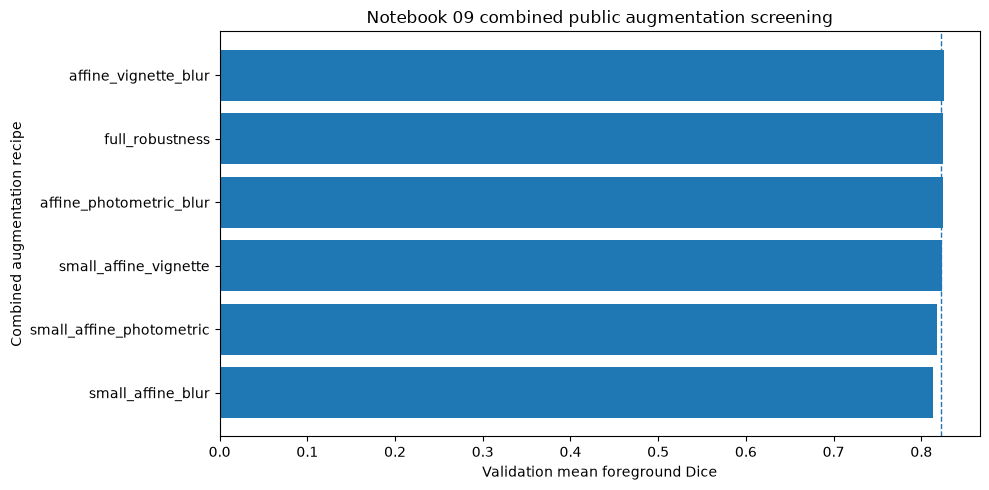

,rank_by_validation_mean_foreground_dice,selected_for_notebook_10,strategy_name,component_strategies,best_epoch_by_val_mean_foreground_dice,best_val_disc_dice,best_val_cup_dice,best_val_mean_foreground_dice,best_val_cdr_mae,delta_vs_notebook_07_reference_val_mean_foreground_dice,meaningful_improvement_vs_notebook_07_reference
0,1,True,combo_affine_vignette_blur,small_affine;vignette_illumination;defocus_blur,4,0.850432,0.800812,0.825622,0.065028,0.002695,False
1,2,False,combo_full_robustness,small_affine;global_photometric;defocus_blur;l...,5,0.846159,0.804298,0.825228,0.065687,0.002301,False
2,3,False,combo_affine_photometric_blur,small_affine;global_photometric;defocus_blur,5,0.854608,0.794434,0.824521,0.073269,0.001594,False
3,4,False,combo_small_affine_vignette,small_affine;vignette_illumination,5,0.852167,0.795468,0.823818,0.063046,0.000891,False
4,5,False,combo_small_affine_photometric,small_affine;global_photometric,4,0.845058,0.791124,0.818091,0.068159,-0.004836,False
5,6,False,combo_small_affine_blur,small_affine;defocus_blur,4,0.843372,0.782277,0.812825,0.070037,-0.010103,False


In [21]:
# 09.21 — Validation comparison visualization

if not SUMMARY_PATH.exists():
    raise FileNotFoundError("Notebook 09 summary not found. Run the summary cell first.")

summary = pd.read_csv(SUMMARY_PATH)
plot_frame = summary.sort_values("best_val_mean_foreground_dice", ascending=True).copy()

labels = plot_frame["strategy_name"].str.replace("combo_", "", regex=False)
values = plot_frame["best_val_mean_foreground_dice"]

plt.figure(figsize=(10, 5))
plt.barh(labels, values)
plt.axvline(reference_val_mean_foreground_dice, linestyle="--", linewidth=1)
plt.xlabel("Validation mean foreground Dice")
plt.ylabel("Combined augmentation recipe")
plt.title("Notebook 09 combined public augmentation screening")
plt.tight_layout()
plt.show()

display(
    summary[
        [
            "rank_by_validation_mean_foreground_dice",
            "selected_for_notebook_10",
            "strategy_name",
            "component_strategies",
            "best_epoch_by_val_mean_foreground_dice",
            "best_val_disc_dice",
            "best_val_cup_dice",
            "best_val_mean_foreground_dice",
            "best_val_cdr_mae",
            "delta_vs_notebook_07_reference_val_mean_foreground_dice",
            "meaningful_improvement_vs_notebook_07_reference",
        ]
    ]
)


## 09.22 — Handoff summary

Notebook 09 screens combined public-data augmentation recipes while keeping the Notebook 07 selected architecture fixed.

The selected recipe should be carried into Notebook 10 for longer public-data training. Clinical evaluation remains reserved for Notebook 11 so that clinical PSD-derived data are not used to select among Notebook 09 augmentation candidates.

In [22]:
# 09.22 — Final handoff summary

if not SUMMARY_PATH.exists():
    raise FileNotFoundError("Notebook 09 summary not found. Run the summary cell first.")

summary = pd.read_csv(SUMMARY_PATH)
selected = summary.loc[summary["selected_for_notebook_10"] == True].iloc[0].to_dict()

handoff = {
    "notebook": "09_combined_public_augmentation_expansion",
    "clinical_data_used": False,
    "test_split_used_for_screening": False,
    "selection_metric": "public validation mean foreground Dice",
    "selected_run_name": selected["run_name"],
    "selected_strategy_name": selected["strategy_name"],
    "selected_component_strategies": selected["component_strategies"],
    "selected_best_val_mean_foreground_dice": selected["best_val_mean_foreground_dice"],
    "notebook_07_reference_run_name": selected["notebook_07_reference_run_name"],
    "notebook_07_reference_val_mean_foreground_dice": selected[
        "notebook_07_reference_val_mean_foreground_dice"
    ],
    "delta_vs_notebook_07_reference_val_mean_foreground_dice": selected[
        "delta_vs_notebook_07_reference_val_mean_foreground_dice"
    ],
    "meaningful_improvement_vs_notebook_07_reference": bool(
        selected["meaningful_improvement_vs_notebook_07_reference"]
    ),
    "next_notebook": "10_long_training_selected_public_model.ipynb",
    "next_step": (
        "Retrain the selected Notebook 09 public-data recipe for 25 epochs, "
        "select the best public validation epoch, and evaluate once on the public held-out test split."
    ),
}

display(pd.DataFrame([handoff]).T.rename(columns={0: "value"}))


,value
notebook,09_combined_public_augmentation_expansion
clinical_data_used,False
test_split_used_for_screening,False
selection_metric,public validation mean foreground Dice
selected_run_name,combined_unetplusplus_resnet18_combo_affine_vi...
selected_strategy_name,combo_affine_vignette_blur
selected_component_strategies,small_affine;vignette_illumination;defocus_blur
selected_best_val_mean_foreground_dice,0.825622
notebook_07_reference_run_name,final_unetplusplus_resnet18_small_affine_virtu...
notebook_07_reference_val_mean_foreground_dice,0.822927
